#Use our fine-tuned version of Parler-TTS

In [ ]:
import locale

def getpreferredencoding(do_setlocale=True):
    return "UTF-8"

locale.getpreferredencoding = getpreferredencoding

In [ ]:
!pip install indic-transliteration transformers torch
!pip install git+https://github.com/huggingface/parler-tts.git

  Cloning https://github.com/huggingface/parler-tts.git to /tmp/pip-req-build-ezsj3flx
  Running command git clone --filter=blob:none --quiet https://github.com/huggingface/parler-tts.git /tmp/pip-req-build-ezsj3flx
  Resolved https://github.com/huggingface/parler-tts.git to commit d108732cd57788ec86bc857d99a6cabd66663d68
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Cloning https://github.com/descriptinc/audiotools to /tmp/pip-install-g2_77fp8/descript-audiotools_b90be604710b4f568794530ec4c5cc3b
  Running command git clone --filter=blob:none --quiet https://github.com/descriptinc/audiotools /tmp/pip-install-g2_77fp8/descript-audiotools_b90be604710b4f568794530ec4c5cc3b
  Resolved https://github.com/descriptinc/audiotools to commit 348ebf2034ce24e2a91a553e3171cb00c0c71678
  Preparing metadata (setup.py) ... done


##Load Model

In [ ]:
from indic_transliteration.sanscript import transliterate, DEVANAGARI, ITRANS
from parler_tts import ParlerTTSForConditionalGeneration
from transformers import AutoTokenizer
import torch

# Device setup
device = "cuda:0" if torch.cuda.is_available() else "cpu"

print(device)
model = ParlerTTSForConditionalGeneration.from_pretrained("En1gma02/Parler-TTS-Mini-v1-English-Emotions").to(device)
tokenizer = AutoTokenizer.from_pretrained("parler-tts/parler_tts_mini_v0.1")


cuda:0


config.json:   0%|          | 0.00/7.11k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.76G [00:00<?, ?B/s]

/usr/local/lib/python3.11/dist-packages/torch/nn/utils/weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)
  "_name_or_path": "google/flan-t5-large",
  "architectures": [
    "T5ForConditionalGeneration"
  ],
  "classifier_dropout": 0.0,
  "d_ff": 2816,
  "d_kv": 64,
  "d_model": 1024,
  "decoder_start_token_id": 0,
  "dense_act_fn": "gelu_new",
  "dropout_rate": 0.1,
  "eos_token_id": 1,
  "feed_forward_proj": "gated-gelu",
  "initializer_factor": 1.0,
  "is_encoder_decoder": true,
  "is_gated_act": true,
  "layer_norm_epsilon": 1e-06,
  "model_type": "t5",
  "n_positions": 512,
  "num_decoder_layers": 24,
  "num_heads": 16,
  "num_layers": 24,
  "output_past": true,
  "pad_token_id": 0,
  "relative_attention_max_distance": 128,
  "relative_attention_num_buckets": 32,
  "tie_word_embeddings": false,
  "transformers_version": "4.46.1",
  "use_cache": true,
  "vocab

generation_config.json:   0%|          | 0.00/265 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/20.8k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.42M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/2.54k [00:00<?, ?B/s]

You set `add_prefix_space`. The tokenizer needs to be converted from the slow tokenizers


##Generate Audio - Emotions
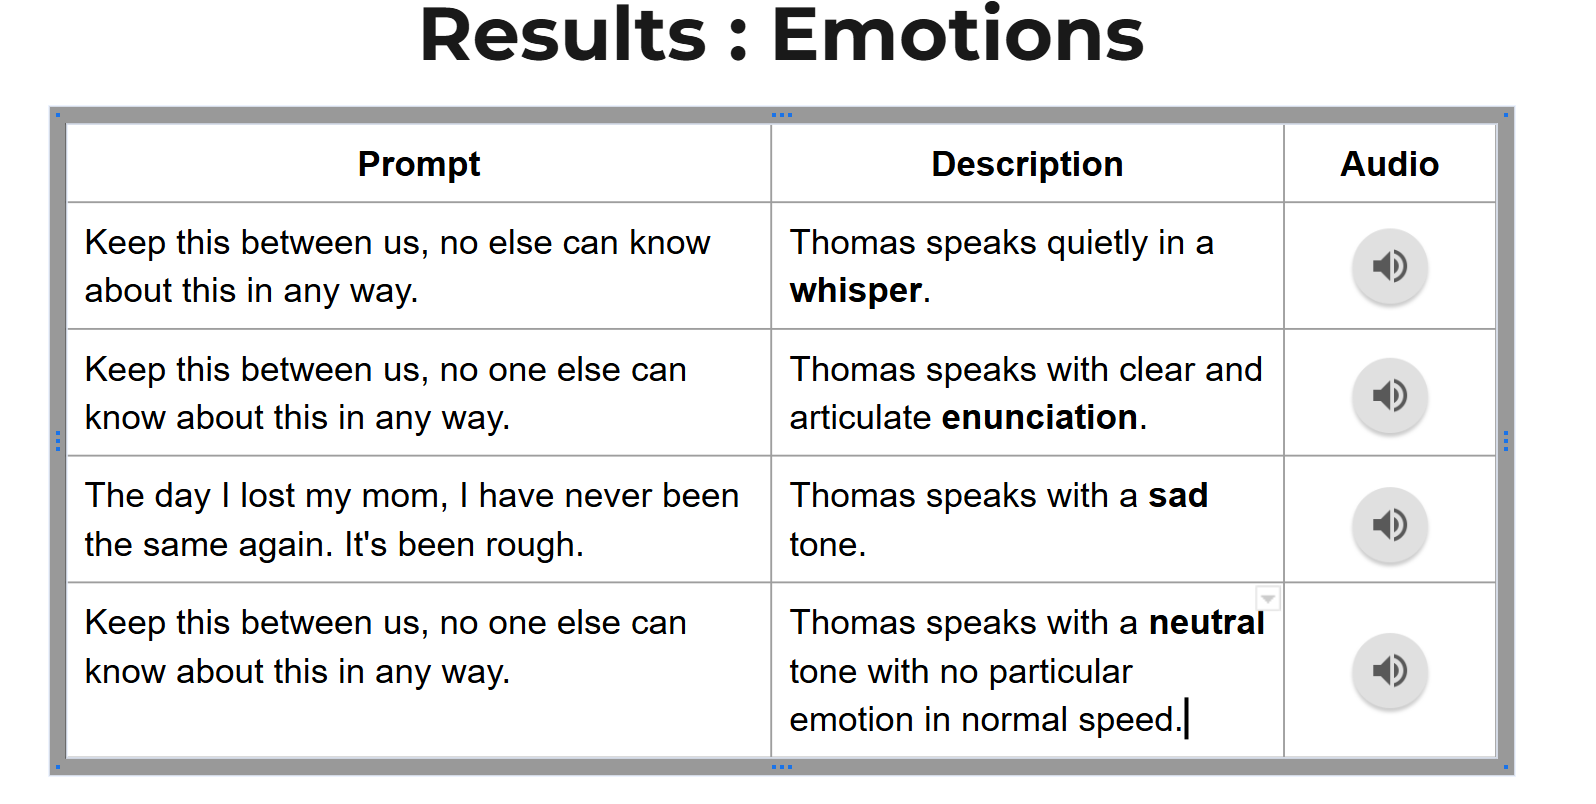

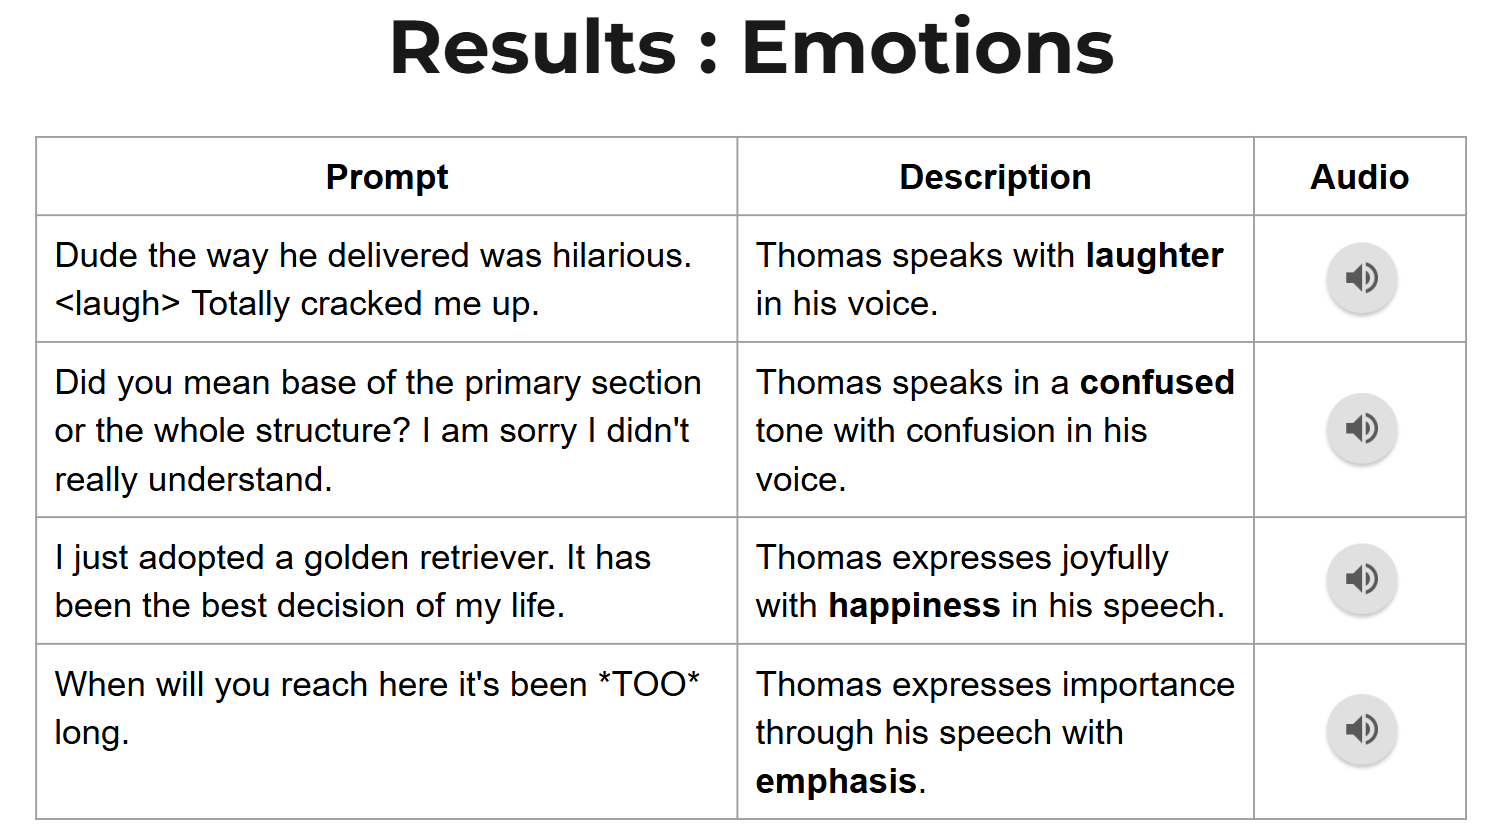

In [ ]:
prompt = "We are doing a presentation of parler text to speech to our faculty."
description = "'Thomas expresses joyfully with happiness.'"

input_ids = tokenizer(description, return_tensors="pt").input_ids.to(device)
prompt_input_ids = tokenizer(prompt, return_tensors="pt").input_ids.to(device)

generation = model.generate(input_ids=input_ids, prompt_input_ids=prompt_input_ids)
audio_arr = generation.cpu().numpy().squeeze()

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


##Listen to Audio

In [ ]:
from IPython.display import Audio
Audio(audio_arr, rate=model.config.sampling_rate)

##Save Audio

In [ ]:
import soundfile as sf
import numpy as np

# Convert audio array to float32
audio_arr_float32 = audio_arr.astype(np.float32)

# Specify the file path where you want to save the audio
output_path = 'generated_audio4.wav'

# Write the converted audio array to a WAV file
sf.write(output_path, audio_arr_float32, model.config.sampling_rate)

print(f"Audio saved to {output_path}")

Audio saved to generated_audio4.wav


In [ ]:
prompt = "We are doing a presentation of parler text to speech to our faculty."
description = "'Thomas speaks with a sad tone'"

input_ids = tokenizer(description, return_tensors="pt").input_ids.to(device)
prompt_input_ids = tokenizer(prompt, return_tensors="pt").input_ids.to(device)

generation = model.generate(input_ids=input_ids, prompt_input_ids=prompt_input_ids)
audio_arr = generation.cpu().numpy().squeeze()

In [ ]:
from IPython.display import Audio
Audio(audio_arr, rate=model.config.sampling_rate)

In [ ]:
prompt = "We are doing a presentation <laugh> of parler text to speech to our faculty."
description = "Thomas speaks with laughter in his voice."

input_ids = tokenizer(description, return_tensors="pt").input_ids.to(device)
prompt_input_ids = tokenizer(prompt, return_tensors="pt").input_ids.to(device)

generation = model.generate(input_ids=input_ids, prompt_input_ids=prompt_input_ids)
audio_arr = generation.cpu().numpy().squeeze()

In [ ]:
from IPython.display import Audio
Audio(audio_arr, rate=model.config.sampling_rate)